# Phase 2b: Feature Interactions

Base: Fase 2 (mejor LB: 0.82174). Se agregan features derivadas de combinar las existentes:

**Ratios físicos** — relaciones entre medidas corporales
- `weight_per_inch`, `vertical_per_height`, `broad_per_height`, `strength_per_weight`, `jump_reach_ratio`

**Productos de rendimiento** — combinaciones multiplicativas entre capacidades
- `sprint_x_bench` (velocidad × fuerza), `power_speed` (peso/sprint), `sprint_x_vertical`, `sprint_x_broad`, `vertical_x_broad`

**Ratios de drill** — relaciones entre métricas de agilidad/velocidad
- `speed_agility_ratio` (Sprint/Agility), `agility_shuttle_ratio`

**Cuadráticos** — capturan no-linealidad de sprint y edad
- `sprint_sq`, `age_sq`

**Interacciones de z-scores** — versión position-normalizada de los productos
- `z_sprint_x_bench`, `z_sprint_x_vertical`, `z_sprint_x_broad`

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

SEED     = 42
N_FOLDS  = 5
TE_ALPHA = 10

INPUT_PATH  = Path('/Users/haroldlagares/Downloads/competition/input')
RESULTS_DIR = Path('/Users/haroldlagares/Downloads/competition/results')
RESULTS_DIR.mkdir(exist_ok=True)

print('LightGBM:', lgb.__version__)

LightGBM: 4.6.0


## 2. Load Data

In [2]:
train_raw = pd.read_csv(INPUT_PATH / 'train.csv')
test_raw  = pd.read_csv(INPUT_PATH / 'test.csv')
print('Train:', train_raw.shape, '| Test:', test_raw.shape)

Train: (2781, 16) | Test: (696, 15)


## 3. Preprocessing base (Fase 2)

In [3]:
NULL_COLS    = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']
PERF_COLS    = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']
INVERSE_COLS = ['Sprint_40yd', 'Agility_3cone', 'Shuttle']
TE_COLS      = ['School', 'Position', 'Position_Type']

train = train_raw.copy()
test  = test_raw.copy()

# Missing flags
for col in NULL_COLS:
    train[f'missing_{col}'] = train[col].isna().astype(np.int8)
    test[f'missing_{col}']  = test[col].isna().astype(np.int8)

# Imputación por grupo
group_medians   = train.groupby('Position_Type')[NULL_COLS].median()
global_fallback = group_medians.median()
for col in NULL_COLS:
    for df in [train, test]:
        mask = df[col].isna()
        if mask.any():
            df.loc[mask, col] = df.loc[mask, 'Position_Type'].map(group_medians[col]).fillna(global_fallback[col])

# BMI
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Z-scores por Position
pos_stats = {}
for col in PERF_COLS:
    pos_stats[col] = {
        'mean': train.groupby('Position')[col].mean(),
        'std':  train.groupby('Position')[col].std().replace(0, np.nan).fillna(1),
    }
for df in [train, test]:
    for col in PERF_COLS:
        z = (df[col] - df['Position'].map(pos_stats[col]['mean'])) / df['Position'].map(pos_stats[col]['std']).replace(0, np.nan).fillna(1)
        df[f'z_{col}'] = -z if col in INVERSE_COLS else z

z_cols = [f'z_{c}' for c in PERF_COLS]
for df in [train, test]:
    df['overall_athleticism'] = df[z_cols].mean(axis=1)

# Label encode Player_Type
le = LabelEncoder()
le.fit(pd.concat([train['Player_Type'], test['Player_Type']], ignore_index=True).astype(str))
train['Player_Type'] = le.transform(train['Player_Type'].astype(str))
test['Player_Type']  = le.transform(test['Player_Type'].astype(str))

# Target encoding estático
def target_encode_static(train_df, apply_df, col, target='Drafted', alpha=10):
    global_mean = train_df[target].mean()
    stats = train_df.groupby(col)[target].agg(['mean', 'count'])
    stats['te'] = (stats['mean'] * stats['count'] + global_mean * alpha) / (stats['count'] + alpha)
    return apply_df[col].map(stats['te']).fillna(global_mean)

for col in TE_COLS:
    train[f'te_{col}'] = target_encode_static(train_raw, train, col, 'Drafted', TE_ALPHA)
    test[f'te_{col}']  = target_encode_static(train_raw, test,  col, 'Drafted', TE_ALPHA)

print('Preprocessing base completo. Nulos restantes:', train[NULL_COLS].isnull().sum().sum())

Preprocessing base completo. Nulos restantes: 0


## 4. Feature Interactions

Todas calculadas **después de imputar** para evitar propagar NaN.

In [4]:
for df in [train, test]:

    # --- Ratios físicos ---
    df['weight_per_inch']     = df['Weight'] / df['Height']
    df['vertical_per_height'] = df['Vertical_Jump'] / df['Height']
    df['broad_per_height']    = df['Broad_Jump'] / df['Height']
    df['strength_per_weight'] = df['Bench_Press_Reps'] / df['Weight']
    df['jump_reach_ratio']    = df['Vertical_Jump'] / df['Broad_Jump']

    # --- Productos velocidad × otras capacidades ---
    # Sprint_40yd: menor = más rápido → invertimos para que el producto vaya en la misma dirección
    inv_sprint = 1.0 / df['Sprint_40yd']
    df['sprint_x_bench']    = inv_sprint * df['Bench_Press_Reps']   # rápido Y fuerte
    df['sprint_x_vertical'] = inv_sprint * df['Vertical_Jump']       # rápido Y explosivo vertical
    df['sprint_x_broad']    = inv_sprint * df['Broad_Jump']          # rápido Y explosivo horizontal
    df['vertical_x_broad']  = df['Vertical_Jump'] * df['Broad_Jump'] # potencia bidimensional

    # --- Power-speed: jugadores pesados que corren rápido ---
    df['power_speed'] = df['Weight'] / df['Sprint_40yd']

    # --- Ratios entre drills de agilidad ---
    df['speed_agility_ratio']   = df['Sprint_40yd'] / df['Agility_3cone']  # negativo con Drafted: si agility cae más que sprint, peor
    df['agility_shuttle_ratio'] = df['Agility_3cone'] / df['Shuttle']

    # --- Cuadráticos (no-linealidad) ---
    df['sprint_sq'] = df['Sprint_40yd'] ** 2
    df['age_sq']    = df['Age'] ** 2

    # --- Interacciones de z-scores (version normalizada por posición) ---
    df['z_sprint_x_bench']    = df['z_Sprint_40yd'] * df['z_Bench_Press_Reps']
    df['z_sprint_x_vertical'] = df['z_Sprint_40yd'] * df['z_Vertical_Jump']
    df['z_sprint_x_broad']    = df['z_Sprint_40yd'] * df['z_Broad_Jump']

INTERACTION_COLS = [
    'weight_per_inch', 'vertical_per_height', 'broad_per_height',
    'strength_per_weight', 'jump_reach_ratio',
    'sprint_x_bench', 'sprint_x_vertical', 'sprint_x_broad', 'vertical_x_broad',
    'power_speed',
    'speed_agility_ratio', 'agility_shuttle_ratio',
    'sprint_sq', 'age_sq',
    'z_sprint_x_bench', 'z_sprint_x_vertical', 'z_sprint_x_broad',
]

# Verificar correlación en train
corrs = train[INTERACTION_COLS + ['Drafted']].corr()['Drafted'].drop('Drafted')
print('Correlación de interactions con Drafted:')
print(corrs.sort_values(key=abs, ascending=False).round(4).to_string())

Correlación de interactions con Drafted:
sprint_x_bench           0.1533
power_speed              0.1458
sprint_x_vertical        0.1169
speed_agility_ratio     -0.1146
sprint_x_broad           0.1115
sprint_sq               -0.1085
vertical_x_broad         0.1075
age_sq                  -0.1030
strength_per_weight      0.0917
vertical_per_height      0.0790
jump_reach_ratio         0.0750
weight_per_inch          0.0704
broad_per_height         0.0576
agility_shuttle_ratio    0.0309
z_sprint_x_vertical     -0.0119
z_sprint_x_bench        -0.0091
z_sprint_x_broad         0.0040


## 5. Feature Set Final

In [5]:
BASE_COLS = [
    'Year', 'Age', 'Height', 'Weight',
    'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle',
    'Player_Type',
    'missing_Age', 'missing_Sprint_40yd', 'missing_Vertical_Jump', 'missing_Bench_Press_Reps',
    'missing_Broad_Jump', 'missing_Agility_3cone', 'missing_Shuttle',
    'BMI',
    'z_Sprint_40yd', 'z_Vertical_Jump', 'z_Bench_Press_Reps', 'z_Broad_Jump', 'z_Agility_3cone', 'z_Shuttle',
    'overall_athleticism',
    'te_School', 'te_Position', 'te_Position_Type',
]

FEATURE_COLS = BASE_COLS + INTERACTION_COLS

TARGET_COL = 'Drafted'
y      = train[TARGET_COL].values
X      = train[FEATURE_COLS].values
X_test = test[FEATURE_COLS].values

print(f'Features Fase 2:  {len(BASE_COLS)}')
print(f'Interactions nuevas: {len(INTERACTION_COLS)}')
print(f'Total features:   {len(FEATURE_COLS)}')

Features Fase 2:  29
Interactions nuevas: 17
Total features:   46


## 6. LightGBM con mismos params que Fase 2

In [6]:
lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'verbose':           -1,
    'seed':              SEED,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []
feature_importances = pd.DataFrame({'feature': FEATURE_COLS})

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    dtrain = lgb.Dataset(X[train_idx], label=y[train_idx], feature_name=FEATURE_COLS)
    dval   = lgb.Dataset(X[val_idx],   label=y[val_idx],   feature_name=FEATURE_COLS, reference=dtrain)

    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

    val_pred = model.predict(X[val_idx])
    fold_auc = roc_auc_score(y[val_idx], val_pred)
    fold_scores.append(fold_auc)

    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / N_FOLDS
    feature_importances[f'fold_{fold}'] = model.feature_importance(importance_type='gain')

    print(f'Fold {fold} | AUC: {fold_auc:.5f} | Best iter: {model.best_iteration}')

oof_auc = roc_auc_score(y, oof_preds)
phase2_oof = 0.82480  # referencia
print(f'\nOOF AUC: {oof_auc:.5f}  (±{np.std(fold_scores):.5f})')
print(f'vs Fase 2: {oof_auc - phase2_oof:+.5f}')

Fold 1 | AUC: 0.82202 | Best iter: 17


Fold 2 | AUC: 0.87062 | Best iter: 27


Fold 3 | AUC: 0.86324 | Best iter: 56


Fold 4 | AUC: 0.81379 | Best iter: 50


Fold 5 | AUC: 0.85279 | Best iter: 61

OOF AUC: 0.83830  (±0.02259)
vs Fase 2: +0.01350


## 7. Feature Importance — Interacciones vs Base

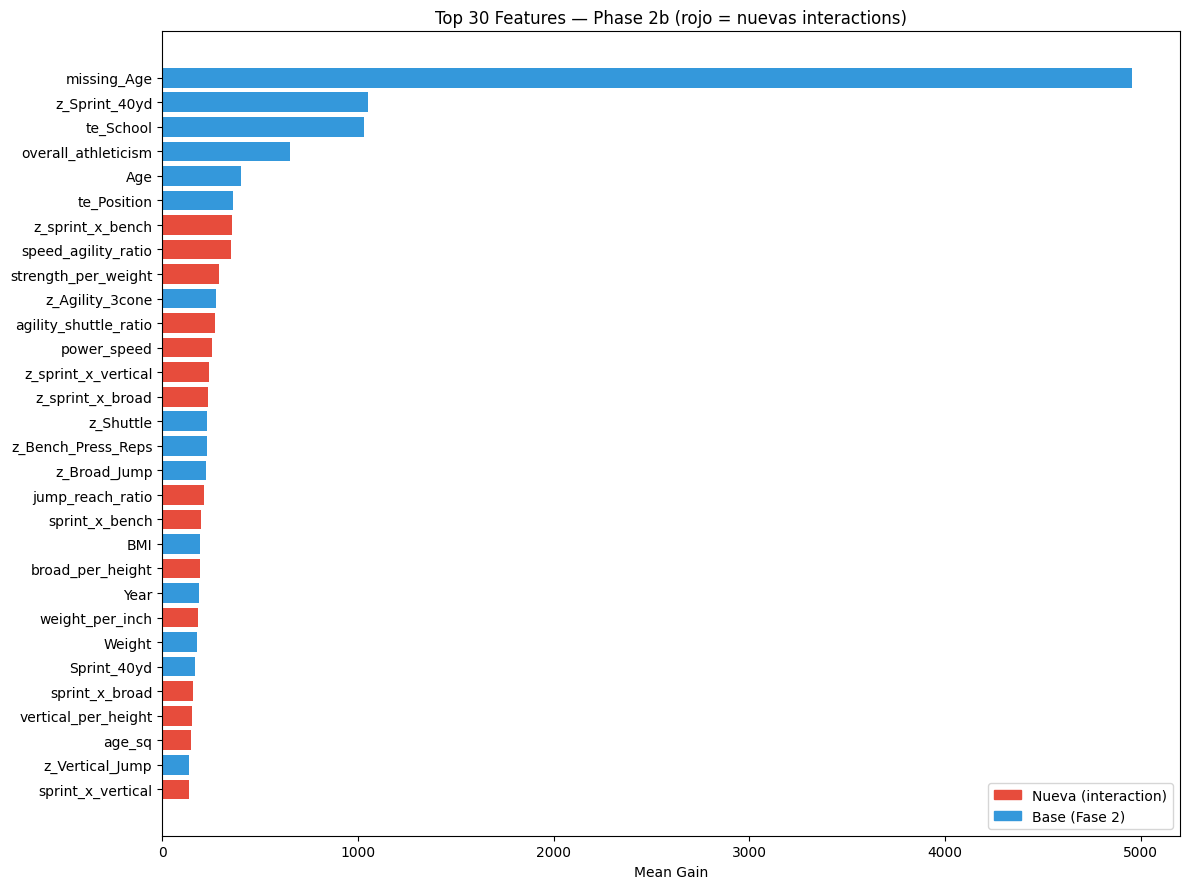


--- Top 15 features ---
              feature   mean_gain  is_new
          missing_Age 4953.750427   False
        z_Sprint_40yd 1049.572116   False
            te_School 1033.141340   False
  overall_athleticism  652.805135   False
                  Age  400.623174   False
          te_Position  364.017580   False
     z_sprint_x_bench  354.054172    True
  speed_agility_ratio  353.018111    True
  strength_per_weight  292.194330    True
      z_Agility_3cone  273.956016   False
agility_shuttle_ratio  268.996347    True
          power_speed  254.028197    True
  z_sprint_x_vertical  239.527282    True
     z_sprint_x_broad  236.067159    True
            z_Shuttle  227.989957   False

--- Nuevas interactions rankeadas ---
              feature  mean_gain
     z_sprint_x_bench 354.054172
  speed_agility_ratio 353.018111
  strength_per_weight 292.194330
agility_shuttle_ratio 268.996347
          power_speed 254.028197
  z_sprint_x_vertical 239.527282
     z_sprint_x_broad 236.067159


In [7]:
fold_cols = [c for c in feature_importances.columns if c.startswith('fold_')]
feature_importances['mean_gain'] = feature_importances[fold_cols].mean(axis=1)
feature_importances = feature_importances.sort_values('mean_gain', ascending=False)

# Marcar cuáles son nuevas
feature_importances['is_new'] = feature_importances['feature'].isin(INTERACTION_COLS)

plt.figure(figsize=(12, 9))
colors = ['#e74c3c' if new else '#3498db'
          for new in feature_importances['is_new'][:30]]
plt.barh(feature_importances['feature'][:30], feature_importances['mean_gain'][:30], color=colors)
plt.xlabel('Mean Gain')
plt.title('Top 30 Features — Phase 2b (rojo = nuevas interactions)')
plt.gca().invert_yaxis()
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#e74c3c', label='Nueva (interaction)'),
                    Patch(color='#3498db', label='Base (Fase 2)')])
plt.tight_layout()
plt.show()

print('\n--- Top 15 features ---')
print(feature_importances[['feature', 'mean_gain', 'is_new']].head(15).to_string(index=False))
print('\n--- Nuevas interactions rankeadas ---')
new_fi = feature_importances[feature_importances['is_new']].copy()
print(new_fi[['feature', 'mean_gain']].to_string(index=False))

## 8. Guardar Submission

In [8]:
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
submission_path = RESULTS_DIR / f'submission_phase2b_{timestamp}.csv'

submission = pd.read_csv(INPUT_PATH / 'sample_submission.csv')
submission['Drafted'] = test_preds
submission.to_csv(submission_path, index=False)

print(f'Submission: {submission_path}')
print(f'OOF AUC: {oof_auc:.5f} (Fase 2: {phase2_oof:.5f}, delta: {oof_auc - phase2_oof:+.5f})')
print(submission.head())

Submission: /Users/haroldlagares/Downloads/competition/results/submission_phase2b_2026-05-14_18-36-48.csv
OOF AUC: 0.83830 (Fase 2: 0.82480, delta: +0.01350)
     Id   Drafted
0  2781  0.723229
1  2782  0.852036
2  2783  0.842824
3  2784  0.882020
4  2785  0.816868
